<a href="https://colab.research.google.com/github/abhinavmarkanda/UCS547-Accelerated-Data-Science/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Fri May  8 06:35:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================
# Install RAPIDS + XGBoost + Dependencies
# ============================================

!pip install -q cudf-cu12 cuml-cu12 cupy-cuda12x \
    --extra-index-url=https://pypi.nvidia.com

!pip install -q xgboost pandas matplotlib seaborn scikit-learn

In [4]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# GPU Libraries
import cudf
import cupy as cp

from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split as gpu_train_test_split
from cuml.metrics import accuracy_score as gpu_accuracy

# CPU Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# XGBoost
import xgboost as xgb

In [5]:
# ============================================
# Load Dataset
# ============================================

columns = [
    'age', 'workclass', 'fnlwgt', 'education',
    'education_num', 'marital_status', 'occupation',
    'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(
    url,
    names=columns,
    sep=', ',
    engine='python'
)

print(df.head())
print("\nDataset Shape:", df.shape)

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [6]:
# ============================================
# Handle Missing Values
# ============================================

df.replace('?', np.nan, inplace=True)

print(df.isnull().sum())

df.dropna(inplace=True)

print("\nShape after removing missing values:", df.shape)

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Shape after removing missing values: (30162, 15)


In [7]:
# ============================================
# Encode Target
# ============================================

df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

print(df['income'].value_counts())

income
0    22654
1     7508
Name: count, dtype: int64


In [8]:
# ============================================
# Feature Types
# ============================================

feature_types = {
    'age': 'Continuous',
    'workclass': 'Categorical',
    'fnlwgt': 'Continuous',
    'education': 'Categorical',
    'education_num': 'Discrete',
    'marital_status': 'Categorical',
    'occupation': 'Categorical',
    'relationship': 'Categorical',
    'race': 'Categorical',
    'sex': 'Binary',
    'capital_gain': 'Continuous',
    'capital_loss': 'Continuous',
    'hours_per_week': 'Continuous',
    'native_country': 'Categorical',
    'income': 'Binary Target'
}

for k, v in feature_types.items():
    print(f"{k:20} --> {v}")

age                  --> Continuous
workclass            --> Categorical
fnlwgt               --> Continuous
education            --> Categorical
education_num        --> Discrete
marital_status       --> Categorical
occupation           --> Categorical
relationship         --> Categorical
race                 --> Categorical
sex                  --> Binary
capital_gain         --> Continuous
capital_loss         --> Continuous
hours_per_week       --> Continuous
native_country       --> Categorical
income               --> Binary Target


In [9]:
# ============================================
# Continuous Features for Histogram Binning
# ============================================

continuous_features = [
    'age',
    'fnlwgt',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

print("GPU Histogram Eligible Features:")
print(continuous_features)

GPU Histogram Eligible Features:
['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']


In [10]:
# ============================================
# Label Encoding
# ============================================

label_encoders = {}

for col in df.select_dtypes(include='object').columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          5   77516          9             13               4   
1   50          4   83311          9             13               2   
2   38          2  215646         11              9               0   
3   53          2  234721          1              7               2   
4   28          2  338409          9             13               2   

   occupation  relationship  race  sex  capital_gain  capital_loss  \
0           0             1     4    1          2174             0   
1           3             0     4    1             0             0   
2           5             1     4    1             0             0   
3           5             0     2    1             0             0   
4           9             5     2    0             0             0   

   hours_per_week  native_country  income  
0              40              38       0  
1              13              38       0  
2              40   

In [12]:
gdf = cudf.DataFrame(df)

print(gdf.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          5   77516          9             13               4   
1   50          4   83311          9             13               2   
2   38          2  215646         11              9               0   
3   53          2  234721          1              7               2   
4   28          2  338409          9             13               2   

   occupation  relationship  race  sex  capital_gain  capital_loss  \
0           0             1     4    1          2174             0   
1           3             0     4    1             0             0   
2           5             1     4    1             0             0   
3           5             0     2    1             0             0   
4           9             5     2    0             0             0   

   hours_per_week  native_country  income  
0              40              38       0  
1              13              38       0  
2              40   

In [14]:
# ============================================
# GPU Histogram Computation
# ============================================

for feature in continuous_features:

    print("\n==============================")
    print("Feature:", feature)
    print("==============================")

    gpu_array = gdf[feature].to_cupy()

    # GPU Histogram
    gpu_hist, gpu_bins = cp.histogram(
        gpu_array,
        bins=10
    )

    # CPU Histogram
    cpu_hist, cpu_bins = np.histogram(
        df[feature],
        bins=10
    )

    print("\nGPU Histogram Counts:")
    print(cp.asnumpy(gpu_hist))

    print("\nCPU Histogram Counts:")
    print(cpu_hist)


Feature: age

GPU Histogram Counts:
[4869 5579 5761 5925 3810 2412 1278  359  114   55]

CPU Histogram Counts:
[4869 5579 5761 5925 3810 2412 1278  359  114   55]

Feature: fnlwgt

GPU Histogram Counts:
[12373 14007  3220   432    94    17     9     5     2     3]

CPU Histogram Counts:
[12373 14007  3220   432    94    17     9     5     2     3]

Feature: capital_gain

GPU Histogram Counts:
[29430   500    79     3     2     0     0     0     0   148]

CPU Histogram Counts:
[29430   500    79     3     2     0     0     0     0   148]

Feature: capital_loss

GPU Histogram Counts:
[28744    17    20   423   751   189    11     0     6     1]

CPU Histogram Counts:
[28744    17    20   423   751   189    11     0     6     1]

Feature: hours_per_week

GPU Histogram Counts:
[  511  1877  1995 16582  3004  3736  1721   421   184   131]

CPU Histogram Counts:
[  511  1877  1995 16582  3004  3736  1721   421   184   131]


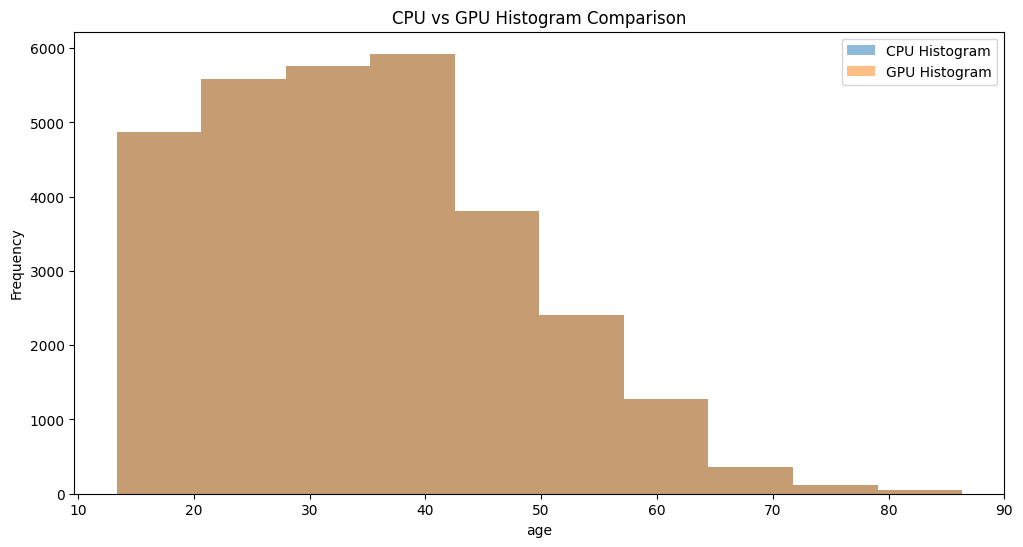

In [15]:
# ============================================
# Histogram Visualization
# ============================================

feature = 'age'

gpu_array = gdf[feature].to_cupy()

gpu_hist, gpu_bins = cp.histogram(
    gpu_array,
    bins=10
)

cpu_hist, cpu_bins = np.histogram(
    df[feature],
    bins=10
)

plt.figure(figsize=(12,6))

plt.bar(
    cpu_bins[:-1],
    cpu_hist,
    width=np.diff(cpu_bins),
    alpha=0.5,
    label='CPU Histogram'
)

plt.bar(
    cp.asnumpy(gpu_bins[:-1]),
    cp.asnumpy(gpu_hist),
    width=cp.asnumpy(cp.diff(gpu_bins)),
    alpha=0.5,
    label='GPU Histogram'
)

plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title("CPU vs GPU Histogram Comparison")
plt.legend()

plt.show()

In [16]:
# ============================================
# GPU Quantile Binning
# ============================================

feature = 'age'

gpu_array = gdf[feature].to_cupy()

quantiles = cp.percentile(
    gpu_array,
    [0, 25, 50, 75, 100]
)

print("Quantile Bin Edges:")
print(cp.asnumpy(quantiles))

Quantile Bin Edges:
[17. 28. 37. 47. 90.]


In [21]:
# ============================================
# Balanced Distribution
# ============================================

# Perform quantile binning on 'age' manually using cupy.digitize
age_cupy = gdf['age'].to_cupy()
quantiles_numpy = cp.asnumpy(quantiles)

# Define the right edges of the bins to match cudf.cut's behavior with right=True and labels=False.
# The quantiles define 4 bins: [q0, q1], (q1, q2], (q2, q3], (q3, q4].
# Using right_edges = [q1, q2, q3, q4] with cp.digitize(..., right=True) produces:
# 0 for x <= q1 (includes q0 to q1)
# 1 for q1 < x <= q2
# 2 for q2 < x <= q3
# 3 for q3 < x <= q4
# This directly corresponds to the desired 0-indexed bins.
right_edges = cp.asarray(quantiles_numpy[1:])

bin_indices = cp.digitize(age_cupy, right_edges, right=True)

# Assign the resulting CuPy array of bin indices to a new cuDF Series
gdf['age_quantile_bin'] = cudf.Series(bin_indices)

distribution = (
    gdf['age_quantile_bin']
    .value_counts()
)

print(distribution)

age_quantile_bin
0    7438
2    6897
1    6826
3    6795
Name: count, dtype: int64


In [22]:
# ============================================
# CPU Model Training
# ============================================

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.time()

cpu_model.fit(X_train, y_train)

cpu_time = time.time() - start

cpu_pred = cpu_model.predict(X_test)

cpu_acc = accuracy_score(
    y_test,
    cpu_pred
)

print("\nCPU Accuracy:", cpu_acc)
print("CPU Training Time:", cpu_time)


CPU Accuracy: 0.8552958727001492
CPU Training Time: 4.366530418395996


In [23]:
# ============================================
# GPU cuML Random Forest
# ============================================

X_gpu = gdf.drop(columns=['income'])
y_gpu = gdf['income']

X_train_g, X_test_g, y_train_g, y_test_g = gpu_train_test_split(
    X_gpu,
    y_gpu,
    test_size=0.2,
    random_state=42
)

gpu_model = cuRF(
    n_estimators=100,
    max_depth=16,
    random_state=42
)

start = time.time()

gpu_model.fit(X_train_g, y_train_g)

gpu_time = time.time() - start

gpu_pred = gpu_model.predict(X_test_g)

gpu_acc = gpu_accuracy(
    y_test_g,
    gpu_pred
)

print("\nGPU Accuracy:", gpu_acc)
print("GPU Training Time:", gpu_time)


GPU Accuracy: 0.8615945632355378
GPU Training Time: 1.1444087028503418


In [25]:
# ============================================
# XGBoost GPU Training
# ============================================

xgb_model = xgb.XGBClassifier(
    tree_method='hist', # Changed from 'gpu_hist' to 'hist'
    predictor='gpu_predictor',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    device='cuda' # Added for explicit GPU utilization
)

start = time.time()

xgb_model.fit(
    X_train,
    y_train
)

xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("\nXGBoost GPU Accuracy:", xgb_acc)
print("XGBoost GPU Training Time:", xgb_time)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost GPU Accuracy: 0.8713741090667992
XGBoost GPU Training Time: 0.5420656204223633


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:44:32] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [26]:
# ============================================
# Final Comparison Table
# ============================================

results = pd.DataFrame({
    'Model': [
        'CPU RandomForest',
        'GPU cuML RandomForest',
        'XGBoost gpu_hist'
    ],
    'Accuracy': [
        cpu_acc,
        float(gpu_acc),
        xgb_acc
    ],
    'Training Time (sec)': [
        cpu_time,
        gpu_time,
        xgb_time
    ]
})

print(results)

                   Model  Accuracy  Training Time (sec)
0       CPU RandomForest  0.855296             4.366530
1  GPU cuML RandomForest  0.861595             1.144409
2       XGBoost gpu_hist  0.871374             0.542066


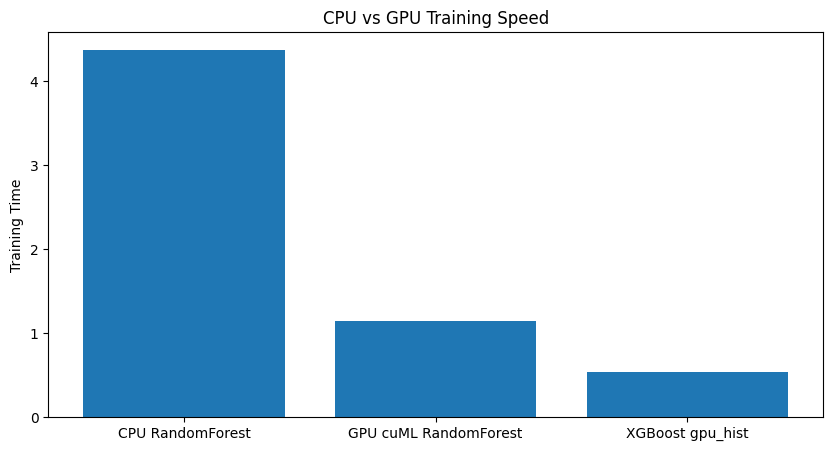

In [27]:
# ============================================
# Training Time Comparison
# ============================================

plt.figure(figsize=(10,5))

plt.bar(
    results['Model'],
    results['Training Time (sec)']
)

plt.ylabel("Training Time")
plt.title("CPU vs GPU Training Speed")

plt.show()

In [28]:
##Q2
!nvidia-smi

Fri May  8 06:45:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             32W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
# ============================================
# Install RAPIDS + ML Libraries
# ============================================

!pip install -q cudf-cu12 cuml-cu12 cupy-cuda12x \
    --extra-index-url=https://pypi.nvidia.com

!pip install -q scikit-learn pandas matplotlib seaborn

In [30]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# sklearn CPU
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# RAPIDS GPU
import cudf
import cupy as cp

from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split as gpu_train_test_split
from cuml.metrics import accuracy_score as gpu_accuracy

In [31]:
# ============================================
# Load Dataset
# ============================================

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("Dataset Shape:", X.shape)

X.head()

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [32]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [34]:
# ============================================
# Convert to cuDF
# ============================================

X_gpu = cudf.DataFrame(X)
y_gpu = cudf.Series(y)

print(X_gpu.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [35]:
# ============================================
# CPU Random Forest
# ============================================

cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training Time
start_train = time.time()

cpu_model.fit(X_train, y_train)

cpu_train_time = time.time() - start_train

# Prediction Time
start_pred = time.time()

cpu_pred = cpu_model.predict(X_test)

cpu_pred_time = time.time() - start_pred

# Accuracy
cpu_acc = accuracy_score(y_test, cpu_pred)

print("CPU Accuracy:", cpu_acc)
print("CPU Training Time:", cpu_train_time)
print("CPU Prediction Time:", cpu_pred_time)

CPU Accuracy: 0.9649122807017544
CPU Training Time: 0.26099300384521484
CPU Prediction Time: 0.015460491180419922


In [36]:
# ============================================
# GPU Train Test Split
# ============================================

X_train_g, X_test_g, y_train_g, y_test_g = gpu_train_test_split(
    X_gpu,
    y_gpu,
    test_size=0.2,
    random_state=42
)

In [37]:
# ============================================
# GPU Random Forest
# ============================================

gpu_model = cuRF(
    n_estimators=100,
    max_depth=16,
    random_state=42
)

# Training Time
start_train = time.time()

gpu_model.fit(X_train_g, y_train_g)

gpu_train_time = time.time() - start_train

# Prediction Time
start_pred = time.time()

gpu_pred = gpu_model.predict(X_test_g)

gpu_pred_time = time.time() - start_pred

# Accuracy
gpu_acc = gpu_accuracy(y_test_g, gpu_pred)

print("GPU Accuracy:", float(gpu_acc))
print("GPU Training Time:", gpu_train_time)
print("GPU Prediction Time:", gpu_pred_time)

GPU Accuracy: 0.9649122807017544
GPU Training Time: 0.34011244773864746
GPU Prediction Time: 0.0061626434326171875


In [38]:
# ============================================
# GPU Speedup
# ============================================

speedup = cpu_train_time / gpu_train_time

print("GPU Speedup over CPU:", speedup)

GPU Speedup over CPU: 0.7673726897692661


In [39]:
# ============================================
# Forest-Level Parallelism
# ============================================

estimators = [1, 10, 50, 100]

cpu_times = []
gpu_times = []

for n in estimators:

    # CPU
    cpu_rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    start = time.time()

    cpu_rf.fit(X_train, y_train)

    cpu_times.append(time.time() - start)

    # GPU
    gpu_rf = cuRF(
        n_estimators=n,
        random_state=42
    )

    start = time.time()

    gpu_rf.fit(X_train_g, y_train_g)

    gpu_times.append(time.time() - start)

print(cpu_times)
print(gpu_times)

[0.0075495243072509766, 0.026887178421020508, 0.13022947311401367, 0.4639861583709717]
[0.010810613632202148, 0.031219959259033203, 0.15222620964050293, 0.2977900505065918]


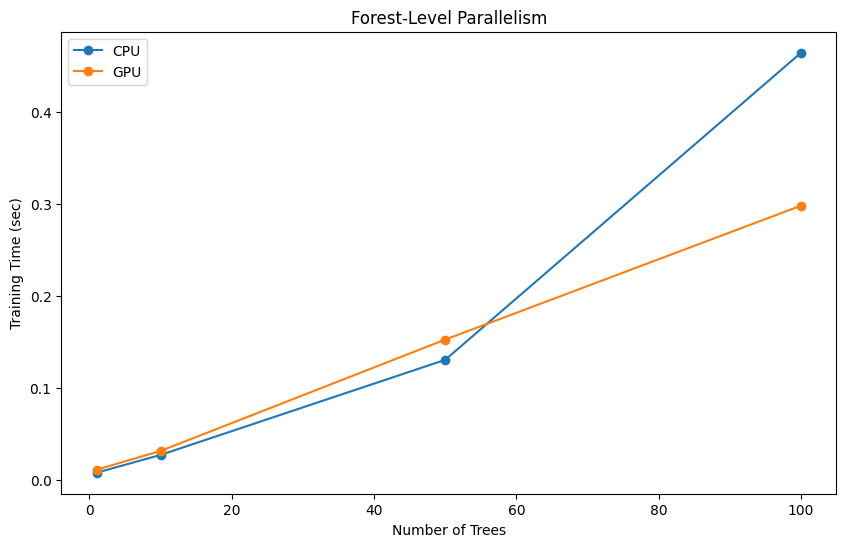

In [40]:
# ============================================
# Plot Forest-Level Parallelism
# ============================================

plt.figure(figsize=(10,6))

plt.plot(
    estimators,
    cpu_times,
    marker='o',
    label='CPU'
)

plt.plot(
    estimators,
    gpu_times,
    marker='o',
    label='GPU'
)

plt.xlabel("Number of Trees")
plt.ylabel("Training Time (sec)")
plt.title("Forest-Level Parallelism")

plt.legend()

plt.show()

In [41]:
# ============================================
# Feature Importance
# ============================================

importance = cpu_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


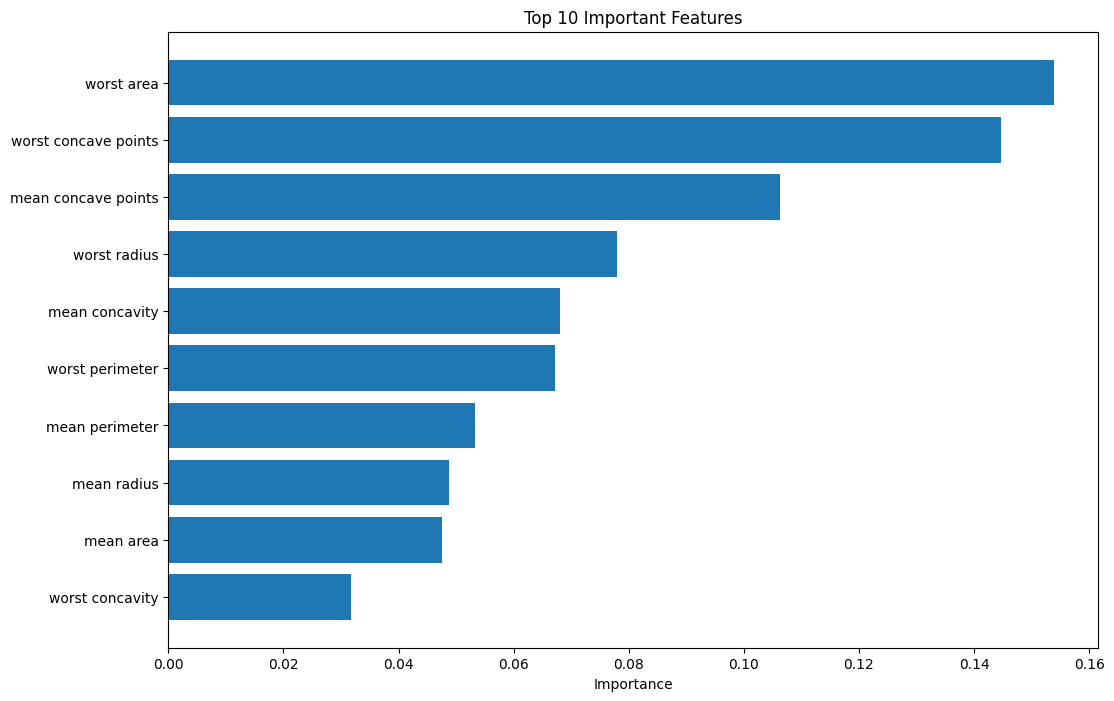

In [42]:
# ============================================
# Plot Feature Importance
# ============================================

plt.figure(figsize=(12,8))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [43]:
# ============================================
# Data-Level Parallelism
# ============================================

sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

gpu_size_times = []

for s in sizes:

    subset_size = int(len(X_gpu) * s)

    X_subset = X_gpu.iloc[:subset_size]
    y_subset = y_gpu.iloc[:subset_size]

    model = cuRF(
        n_estimators=100,
        random_state=42
    )

    start = time.time()

    model.fit(X_subset, y_subset)

    elapsed = time.time() - start

    gpu_size_times.append(elapsed)

print(gpu_size_times)

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


[0.24251151084899902, 0.2932248115539551, 0.27947092056274414, 0.2613201141357422, 0.2989838123321533]


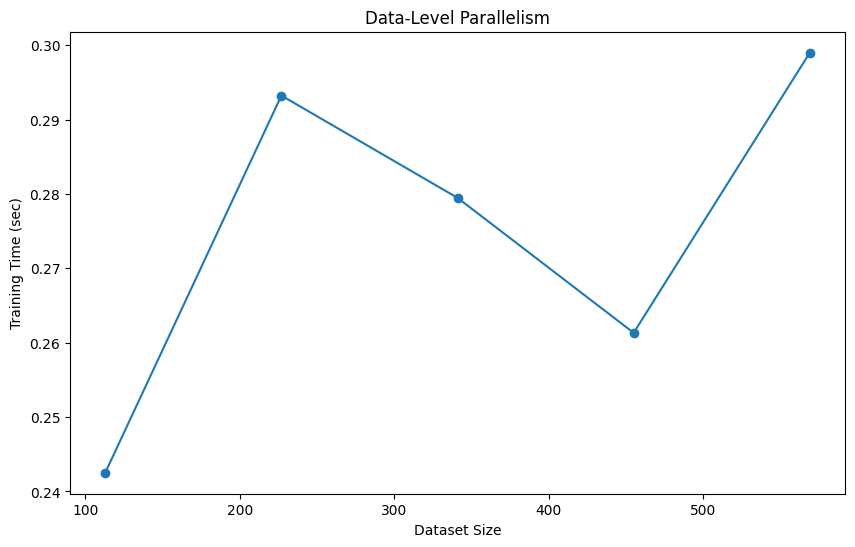

In [44]:
# ============================================
# Plot Data-Level Parallelism
# ============================================

plt.figure(figsize=(10,6))

plt.plot(
    [int(len(X)*s) for s in sizes],
    gpu_size_times,
    marker='o'
)

plt.xlabel("Dataset Size")
plt.ylabel("Training Time (sec)")
plt.title("Data-Level Parallelism")

plt.show()

In [45]:
# ============================================
# Bin-Level Parallelism
# ============================================

feature = 'mean radius'

gpu_array = X_gpu[feature].to_cupy()

gpu_hist, gpu_bins = cp.histogram(
    gpu_array,
    bins=10
)

cpu_hist, cpu_bins = np.histogram(
    X[feature],
    bins=10
)

print("GPU Histogram:")
print(cp.asnumpy(gpu_hist))

print("\nCPU Histogram:")
print(cpu_hist)

GPU Histogram:
[ 19  79 185 129  55  50  38   7   4   3]

CPU Histogram:
[ 19  79 185 129  55  50  38   7   4   3]


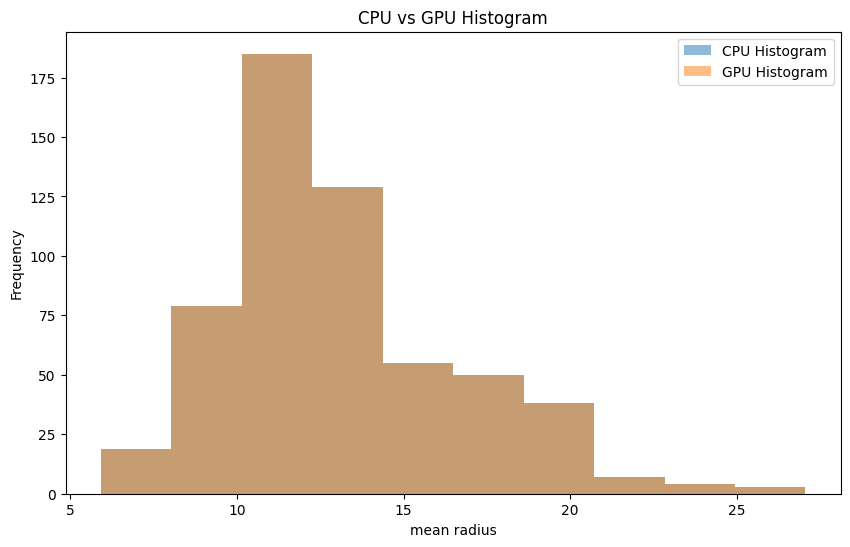

In [46]:
# ============================================
# Histogram Visualization
# ============================================

plt.figure(figsize=(10,6))

plt.bar(
    cpu_bins[:-1],
    cpu_hist,
    width=np.diff(cpu_bins),
    alpha=0.5,
    label='CPU Histogram'
)

plt.bar(
    cp.asnumpy(gpu_bins[:-1]),
    cp.asnumpy(gpu_hist),
    width=cp.asnumpy(cp.diff(gpu_bins)),
    alpha=0.5,
    label='GPU Histogram'
)

plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title("CPU vs GPU Histogram")

plt.legend()

plt.show()

In [47]:
# ============================================
# Performance Comparison Table
# ============================================

results = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Training Time',
        'Prediction Time'
    ],

    'CPU': [
        cpu_acc,
        cpu_train_time,
        cpu_pred_time
    ],

    'GPU': [
        float(gpu_acc),
        gpu_train_time,
        gpu_pred_time
    ]
})

print(results)

            Metric       CPU       GPU
0         Accuracy  0.964912  0.964912
1    Training Time  0.260993  0.340112
2  Prediction Time  0.015460  0.006163


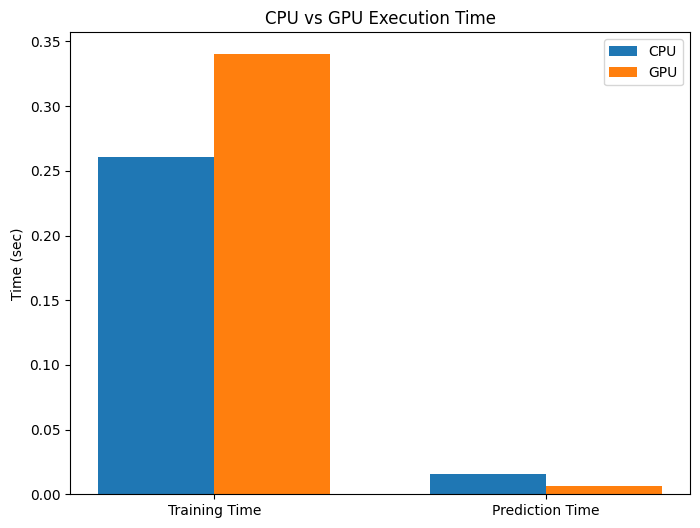

In [48]:
# ============================================
# Execution Time Visualization
# ============================================

metrics = ['Training Time', 'Prediction Time']

cpu_values = [
    cpu_train_time,
    cpu_pred_time
]

gpu_values = [
    gpu_train_time,
    gpu_pred_time
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    cpu_values,
    width,
    label='CPU'
)

plt.bar(
    x + width/2,
    gpu_values,
    width,
    label='GPU'
)

plt.xticks(x, metrics)

plt.ylabel("Time (sec)")
plt.title("CPU vs GPU Execution Time")

plt.legend()

plt.show()